<a href="https://colab.research.google.com/github/kupadhyay5518/Land-Price-Prediction/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn --quiet
print('✅ Libraries ready!')

✅ Libraries ready!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

print('✅ All libraries imported!')

✅ All libraries imported!


In [3]:
N = 2000

# City-wise base price per sq ft (₹)
city_config = {
    'Mumbai':    {'base': 85000, 'std': 15000},
    'Delhi':     {'base': 72000, 'std': 13000},
    'Bangalore': {'base': 65000, 'std': 12000},
    'Hyderabad': {'base': 52000, 'std': 10000},
    'Chennai':   {'base': 48000, 'std': 9000},
    'Pune':      {'base': 45000, 'std': 8500},
    'Kolkata':   {'base': 38000, 'std': 7000},
    'Ahmedabad': {'base': 33000, 'std': 6000},
    'Jaipur':    {'base': 28000, 'std': 5500},
    'Lucknow':   {'base': 22000, 'std': 4500},
}

zone_multiplier   = {'Commercial': 1.6, 'Residential': 1.0, 'Industrial': 0.8, 'Agricultural': 0.4}
road_multiplier   = {'Highway': 1.4, 'Main Road': 1.2, 'Internal Road': 1.0, 'No Road': 0.7}
soil_multiplier   = {'Rocky': 0.85, 'Clay': 0.90, 'Sandy': 0.95, 'Loamy': 1.10}

cities      = np.random.choice(list(city_config.keys()), N)
zones       = np.random.choice(list(zone_multiplier.keys()), N, p=[0.25, 0.45, 0.20, 0.10])
road_types  = np.random.choice(list(road_multiplier.keys()), N, p=[0.15, 0.35, 0.35, 0.15])
soil_types  = np.random.choice(list(soil_multiplier.keys()), N)
area_sqft   = np.random.randint(500, 10001, N)          # 500 – 10,000 sq ft
distance_km = np.round(np.random.uniform(0.5, 30, N), 1) # distance from city center
floors_allowed = np.random.randint(1, 11, N)             # permissible floors
age_years   = np.random.randint(0, 31, N)                # age of registration
has_water   = np.random.choice([0, 1], N, p=[0.3, 0.7])
has_electricity = np.random.choice([0, 1], N, p=[0.2, 0.8])

# ── Price calculation ──────────────────────────────────────────────────────
prices = []
for i in range(N):
    cfg   = city_config[cities[i]]
    base  = np.random.normal(cfg['base'], cfg['std'])
    base  = max(base, cfg['base'] * 0.4)          # floor

    price = (base * area_sqft[i]
             * zone_multiplier[zones[i]]
             * road_multiplier[road_types[i]]
             * soil_multiplier[soil_types[i]]
             * max(0.5, 1 - distance_km[i] * 0.012)   # distance penalty
             * (1 + floors_allowed[i] * 0.04)          # floor bonus
             * max(0.7, 1 - age_years[i] * 0.008)      # age decay
             * (1 + has_water[i] * 0.05)
             * (1 + has_electricity[i] * 0.04)
            )
    price += np.random.normal(0, price * 0.05)    # 5% noise
    prices.append(round(max(price, 50000), -3))   # min ₹50k, round to 1000

df = pd.DataFrame({
    'city'           : cities,
    'zone'           : zones,
    'road_type'      : road_types,
    'soil_type'      : soil_types,
    'area_sqft'      : area_sqft,
    'distance_km'    : distance_km,
    'floors_allowed' : floors_allowed,
    'age_years'      : age_years,
    'water_supply'   : has_water,
    'electricity'    : has_electricity,
    'price_inr'      : prices,
})

df['price_lakhs'] = (df['price_inr'] / 1e5).round(2)

print(f'✅ Dataset generated! Shape: {df.shape}')
df.head(10)

✅ Dataset generated! Shape: (2000, 12)


,city,zone,road_type,soil_type,area_sqft,distance_km,floors_allowed,age_years,water_supply,electricity,price_inr,price_lakhs
0,Kolkata,Residential,Internal Road,Clay,9280,3.3,6,22,1,1,358619000.0,3586.19
1,Hyderabad,Residential,No Road,Rocky,7054,15.9,2,8,1,1,229636000.0,2296.36
2,Ahmedabad,Industrial,No Road,Sandy,8502,25.2,5,16,1,0,156109000.0,1561.09
3,Chennai,Commercial,Internal Road,Clay,5346,25.0,3,20,0,1,218840000.0,2188.40
4,Kolkata,Residential,Internal Road,Clay,9686,28.7,7,27,1,1,206855000.0,2068.55
5,Lucknow,Industrial,Internal Road,Loamy,5298,21.1,4,12,1,0,88535000.0,885.35
6,Bangalore,Residential,Internal Road,Loamy,7105,6.6,1,2,0,1,338461000.0,3384.61
7,Kolkata,Residential,No Road,Clay,3486,1.1,6,3,0,1,92415000.0,924.15
8,Ahmedabad,Agricultural,Main Road,Rocky,900,14.6,6,3,1,1,11034000.0,110.34
9,Chennai,Industrial,No Road,Rocky,3355,15.7,7,10,1,1,80950000.0,809.50


In [4]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df[['area_sqft', 'distance_km', 'floors_allowed', 'age_years', 'price_lakhs']].describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   city            2000 non-null   object 
 1   zone            2000 non-null   object 
 2   road_type       2000 non-null   object 
 3   soil_type       2000 non-null   object 
 4   area_sqft       2000 non-null   int64  
 5   distance_km     2000 non-null   float64
 6   floors_allowed  2000 non-null   int64  
 7   age_years       2000 non-null   int64  
 8   water_supply    2000 non-null   int64  
 9   electricity     2000 non-null   int64  
 10  price_inr       2000 non-null   float64
 11  price_lakhs     2000 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 187.6+ KB
None

=== Missing Values ===
city              0
zone              0
road_type         0
soil_type         0
area_sqft         0
distance_km       0
floors_allowed    0
age_years

,area_sqft,distance_km,floors_allowed,age_years,price_lakhs
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,5175.85,15.35,5.50,15.10,2532.56
std,2732.62,8.47,2.88,9.02,2241.00
min,502.00,0.50,1.00,0.00,61.79
25%,2837.25,8.28,3.00,7.00,941.76
50%,5142.00,15.45,5.00,16.00,1897.50
75%,7504.25,22.60,8.00,23.00,3449.12
max,9996.00,30.00,10.00,30.00,18077.26


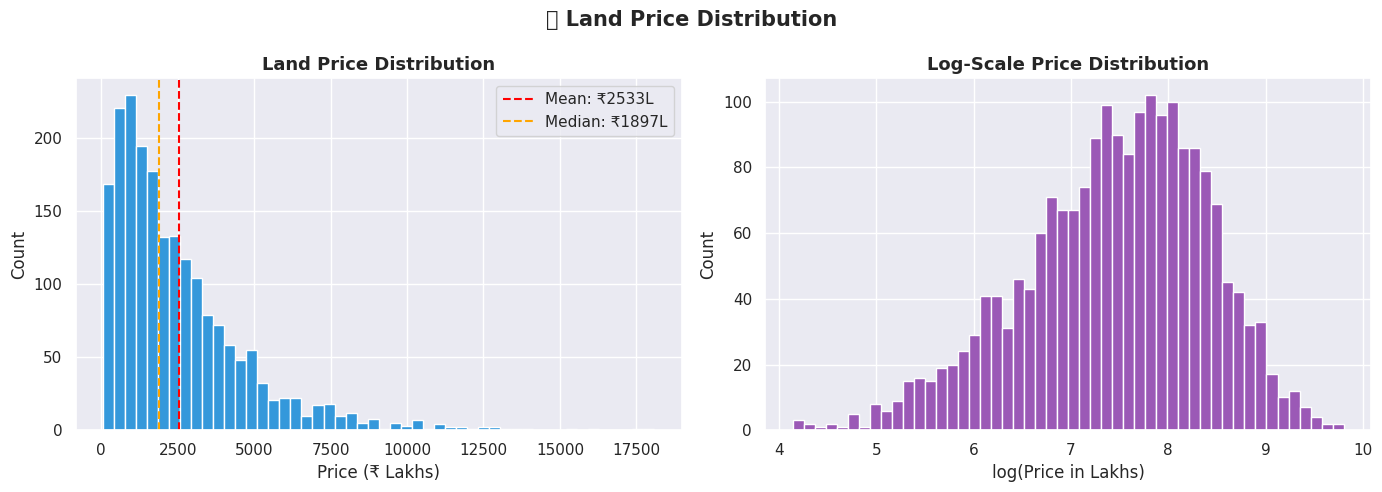

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution
axes[0].hist(df['price_lakhs'], bins=50, color='#3498db', edgecolor='white')
axes[0].axvline(df['price_lakhs'].mean(), color='red', linestyle='--',
                label=f'Mean: ₹{df["price_lakhs"].mean():.0f}L')
axes[0].axvline(df['price_lakhs'].median(), color='orange', linestyle='--',
                label=f'Median: ₹{df["price_lakhs"].median():.0f}L')
axes[0].set_title('Land Price Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (₹ Lakhs)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Log-scale distribution
axes[1].hist(np.log1p(df['price_lakhs']), bins=50, color='#9b59b6', edgecolor='white')
axes[1].set_title('Log-Scale Price Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Price in Lakhs)')
axes[1].set_ylabel('Count')

plt.suptitle('🏡 Land Price Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

In [6]:
city_stats = df.groupby('city')['price_lakhs'].agg(['mean', 'median', 'min', 'max']).round(1)
city_stats.columns = ['Mean', 'Median', 'Min', 'Max']
city_stats = city_stats.sort_values('Mean', ascending=False)

print('🌆 City-wise Price Statistics (₹ Lakhs):')
print(city_stats.to_string())

🌆 City-wise Price Statistics (₹ Lakhs):
             Mean  Median    Min      Max
city                                     
Mumbai     4205.9  3640.4  267.9  18077.3
Delhi      3530.0  2661.6  190.4  13087.6
Bangalore  3283.2  2705.3  159.2  14037.9
Hyderabad  2841.8  2265.8  139.4  11528.2
Chennai    2426.3  2120.4  119.6  10584.6
Pune       2251.4  1822.8   68.4   7790.2
Kolkata    2198.8  1861.6  141.8  12685.7
Ahmedabad  1792.2  1557.2  110.3   6544.3
Jaipur     1452.0  1188.0   73.6   5407.1
Lucknow    1175.6   940.2   61.8   8041.0


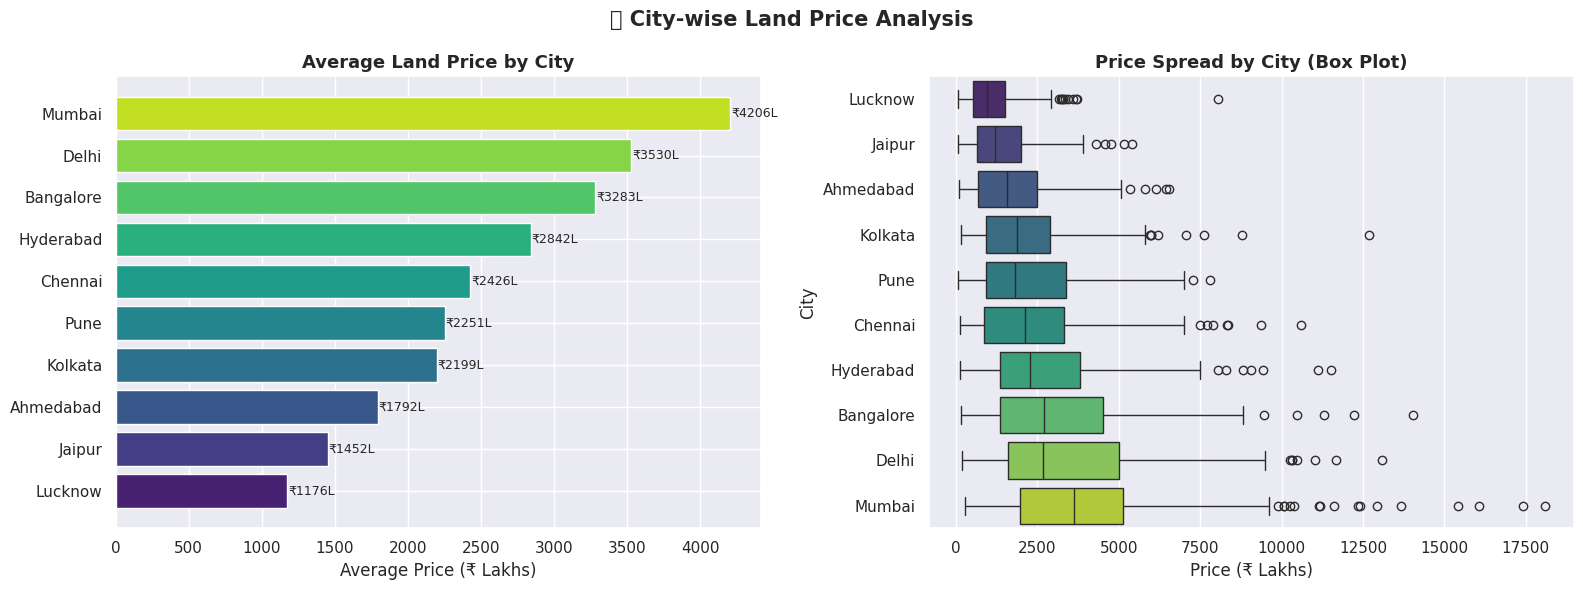

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average price by city
city_avg = city_stats['Mean'].sort_values()
bars = axes[0].barh(city_avg.index, city_avg.values,
                    color=sns.color_palette('viridis', len(city_avg)))
axes[0].set_title('Average Land Price by City', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Price (₹ Lakhs)')
for bar, val in zip(bars, city_avg.values):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'₹{val:.0f}L', va='center', fontsize=9)

# Box plot by city
city_order = city_stats.index.tolist()[::-1]
df_plot = df[df['city'].isin(city_order)]
sns.boxplot(data=df_plot, x='price_lakhs', y='city', order=city_order,
            palette='viridis', ax=axes[1])
axes[1].set_title('Price Spread by City (Box Plot)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price (₹ Lakhs)')
axes[1].set_ylabel('City')

plt.suptitle('🌆 City-wise Land Price Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('city_price_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

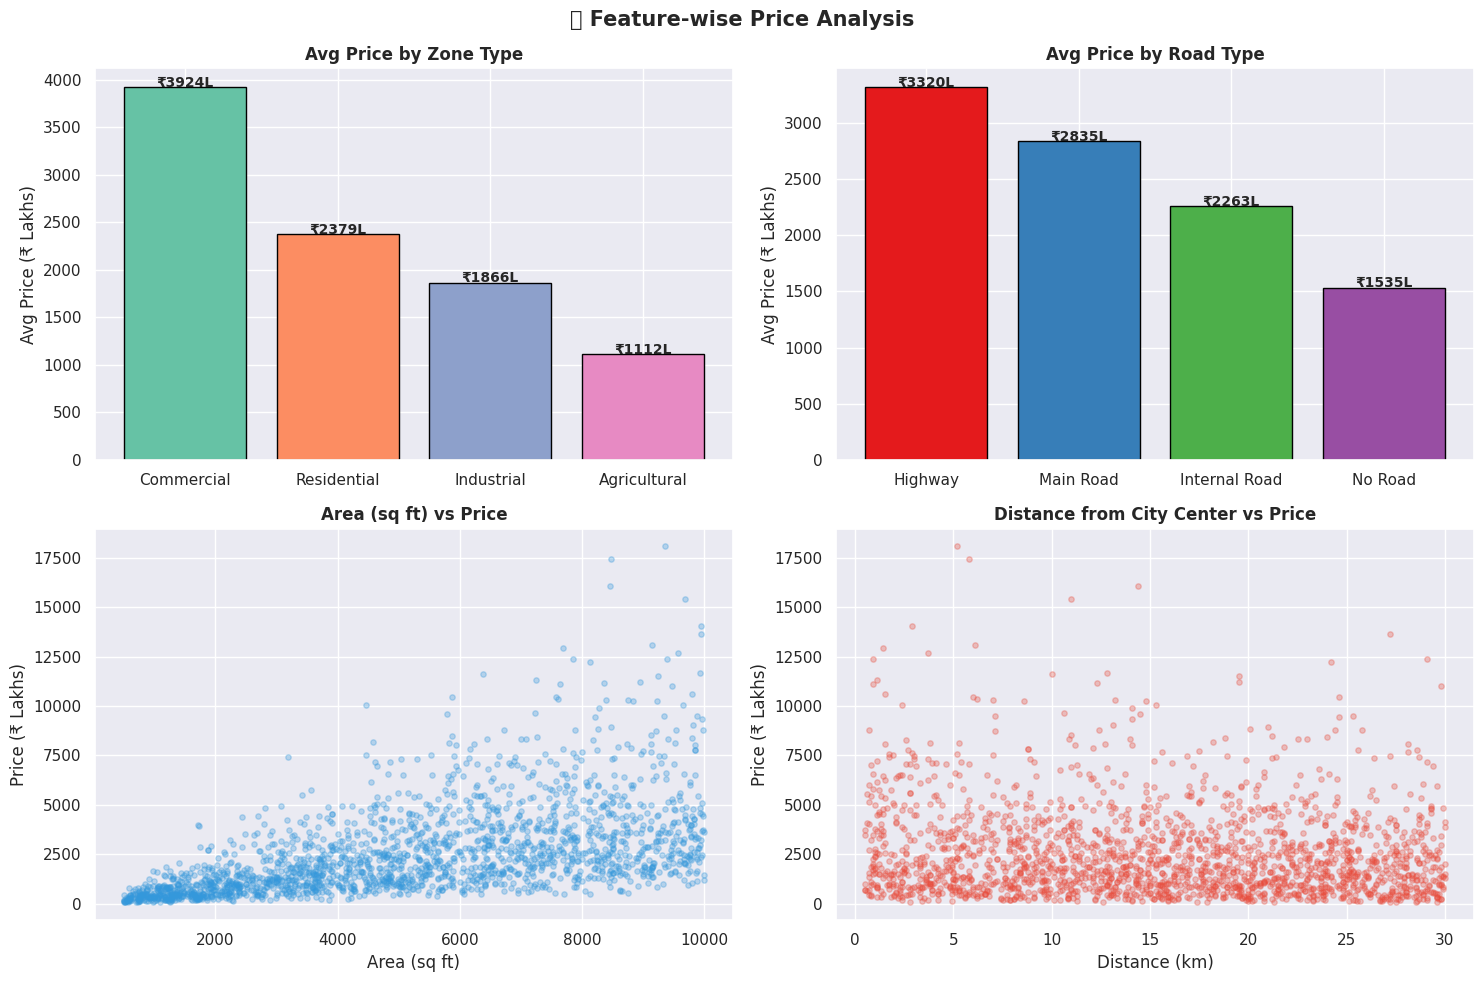

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Zone vs Price
zone_avg = df.groupby('zone')['price_lakhs'].mean().sort_values(ascending=False)
axes[0, 0].bar(zone_avg.index, zone_avg.values,
               color=sns.color_palette('Set2', len(zone_avg)), edgecolor='black')
axes[0, 0].set_title('Avg Price by Zone Type', fontweight='bold')
axes[0, 0].set_ylabel('Avg Price (₹ Lakhs)')
for i, v in enumerate(zone_avg.values):
    axes[0, 0].text(i, v + 2, f'₹{v:.0f}L', ha='center', fontsize=10, fontweight='bold')

# Road Type vs Price
road_avg = df.groupby('road_type')['price_lakhs'].mean().sort_values(ascending=False)
axes[0, 1].bar(road_avg.index, road_avg.values,
               color=sns.color_palette('Set1', len(road_avg)), edgecolor='black')
axes[0, 1].set_title('Avg Price by Road Type', fontweight='bold')
axes[0, 1].set_ylabel('Avg Price (₹ Lakhs)')
for i, v in enumerate(road_avg.values):
    axes[0, 1].text(i, v + 2, f'₹{v:.0f}L', ha='center', fontsize=10, fontweight='bold')

# Area vs Price scatter
axes[1, 0].scatter(df['area_sqft'], df['price_lakhs'],
                   alpha=0.3, color='#3498db', s=15)
axes[1, 0].set_title('Area (sq ft) vs Price', fontweight='bold')
axes[1, 0].set_xlabel('Area (sq ft)')
axes[1, 0].set_ylabel('Price (₹ Lakhs)')

# Distance vs Price scatter
axes[1, 1].scatter(df['distance_km'], df['price_lakhs'],
                   alpha=0.3, color='#e74c3c', s=15)
axes[1, 1].set_title('Distance from City Center vs Price', fontweight='bold')
axes[1, 1].set_xlabel('Distance (km)')
axes[1, 1].set_ylabel('Price (₹ Lakhs)')

plt.suptitle('🏗️ Feature-wise Price Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

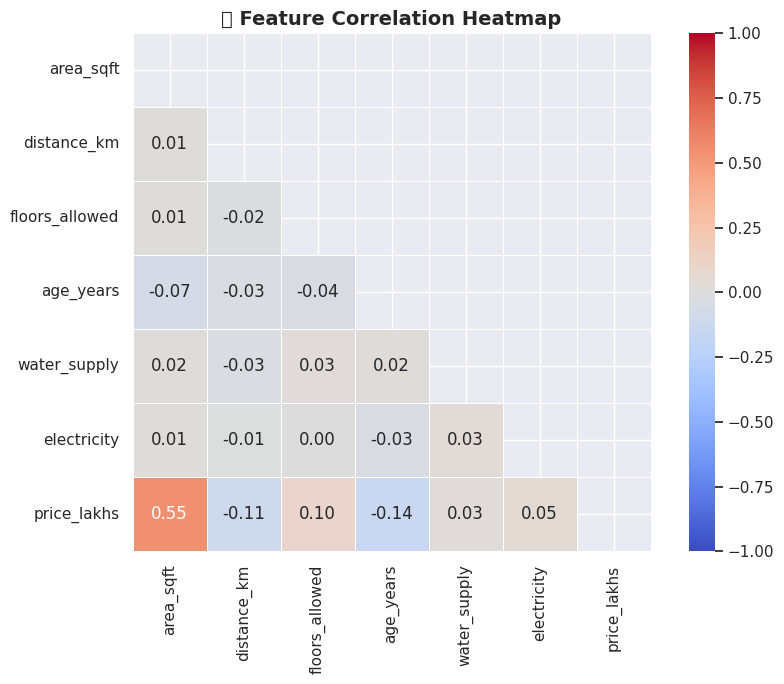

In [9]:
num_cols = ['area_sqft', 'distance_km', 'floors_allowed',
            'age_years', 'water_supply', 'electricity', 'price_lakhs']

corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('🔥 Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

In [10]:
df_model = df.copy()

# Label encode categorical columns
le = LabelEncoder()
cat_cols = ['city', 'zone', 'road_type', 'soil_type']
for col in cat_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])

# Feature matrix
feature_cols = [
    'city_enc', 'zone_enc', 'road_type_enc', 'soil_type_enc',
    'area_sqft', 'distance_km', 'floors_allowed',
    'age_years', 'water_supply', 'electricity'
]

X = df_model[feature_cols].copy()
y = df_model['price_lakhs'].copy()

# Train-Test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features for Linear Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Features ready!')
print(f'   Training rows : {X_train.shape[0]}')
print(f'   Test rows     : {X_test.shape[0]}')
print(f'   Features used : {feature_cols}')

✅ Features ready!
   Training rows : 1600
   Test rows     : 400
   Features used : ['city_enc', 'zone_enc', 'road_type_enc', 'soil_type_enc', 'area_sqft', 'distance_km', 'floors_allowed', 'age_years', 'water_supply', 'electricity']


In [11]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n📊 {name}')
    print(f'   MAE  : ₹{mae:.2f} Lakhs')
    print(f'   RMSE : ₹{rmse:.2f} Lakhs')
    print(f'   R²   : {r2:.4f}  ({r2*100:.2f}% variance explained)')
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'preds': y_pred}

results = {}

# ── 1. Linear Regression ─────────────────────────────────────────────────
print('🔄 Training Linear Regression...')
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
results['Linear Regression'] = evaluate('Linear Regression', y_test, lr.predict(X_test_sc))

# ── 2. Random Forest ─────────────────────────────────────────────────────
print('\n🔄 Training Random Forest...')
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results['Random Forest'] = evaluate('Random Forest', y_test, rf.predict(X_test))

# ── 3. Gradient Boosting ─────────────────────────────────────────────────
print('\n🔄 Training Gradient Boosting...')
gb = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1,
                                max_depth=4, random_state=42)
gb.fit(X_train, y_train)
results['Gradient Boosting'] = evaluate('Gradient Boosting', y_test, gb.predict(X_test))

best_name = max(results, key=lambda m: results[m]['R2'])
print(f'\n🏆 Best Model: {best_name} (R² = {results[best_name]["R2"]*100:.2f}%)')

🔄 Training Linear Regression...

📊 Linear Regression
   MAE  : ₹1220.46 Lakhs
   RMSE : ₹1750.34 Lakhs
   R²   : 0.3796  (37.96% variance explained)

🔄 Training Random Forest...

📊 Random Forest
   MAE  : ₹723.56 Lakhs
   RMSE : ₹1097.27 Lakhs
   R²   : 0.7562  (75.62% variance explained)

🔄 Training Gradient Boosting...

📊 Gradient Boosting
   MAE  : ₹603.27 Lakhs
   RMSE : ₹991.30 Lakhs
   R²   : 0.8010  (80.10% variance explained)

🏆 Best Model: Gradient Boosting (R² = 80.10%)


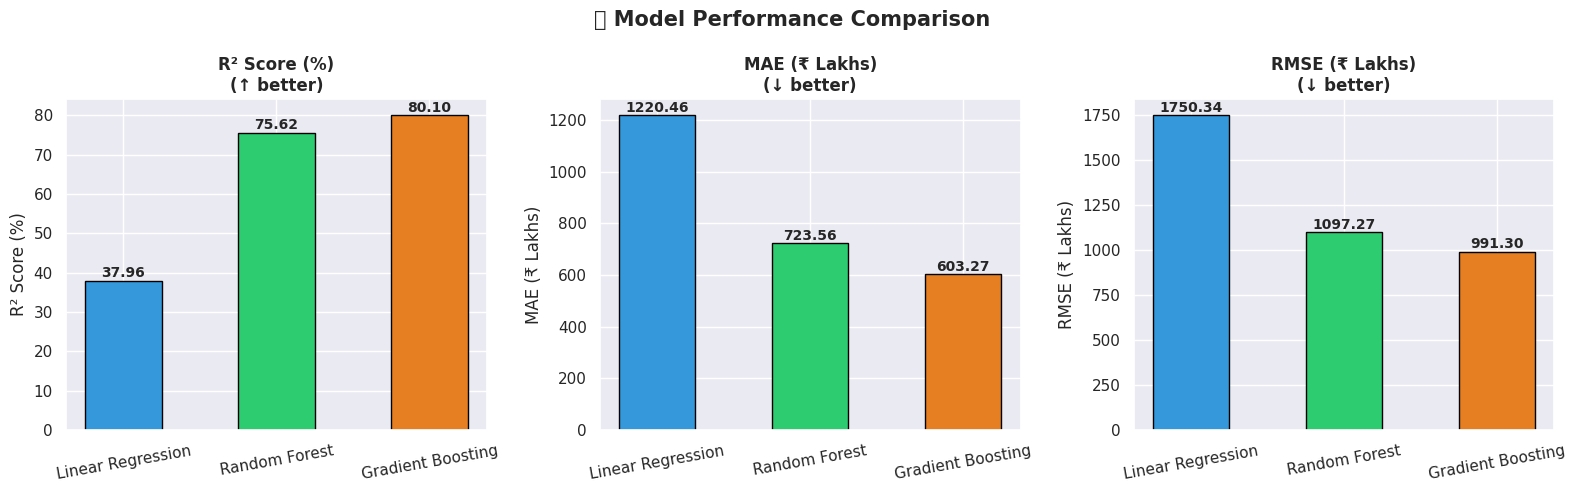

            Model      MAE     RMSE  R2 (%)
Linear Regression 1220.462 1750.338  37.963
    Random Forest  723.559 1097.272  75.620
Gradient Boosting  603.266  991.298  80.102


In [12]:
metrics_df = pd.DataFrame([
    {'Model': k, 'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R2 (%)': v['R2']*100}
    for k, v in results.items()
])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#3498db', '#2ecc71', '#e67e22']

for ax, metric, label, better in zip(
    axes,
    ['R2 (%)', 'MAE', 'RMSE'],
    ['R² Score (%)', 'MAE (₹ Lakhs)', 'RMSE (₹ Lakhs)'],
    ['higher', 'lower', 'lower']
):
    bars = ax.bar(metrics_df['Model'], metrics_df[metric],
                  color=colors, edgecolor='black', width=0.5)
    ax.set_title(f'{label}\n(↑ better)' if better=='higher' else f'{label}\n(↓ better)',
                 fontweight='bold')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=10)
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(metrics_df[metric])*0.01,
                f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('🤖 Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print(metrics_df.round(3).to_string(index=False))

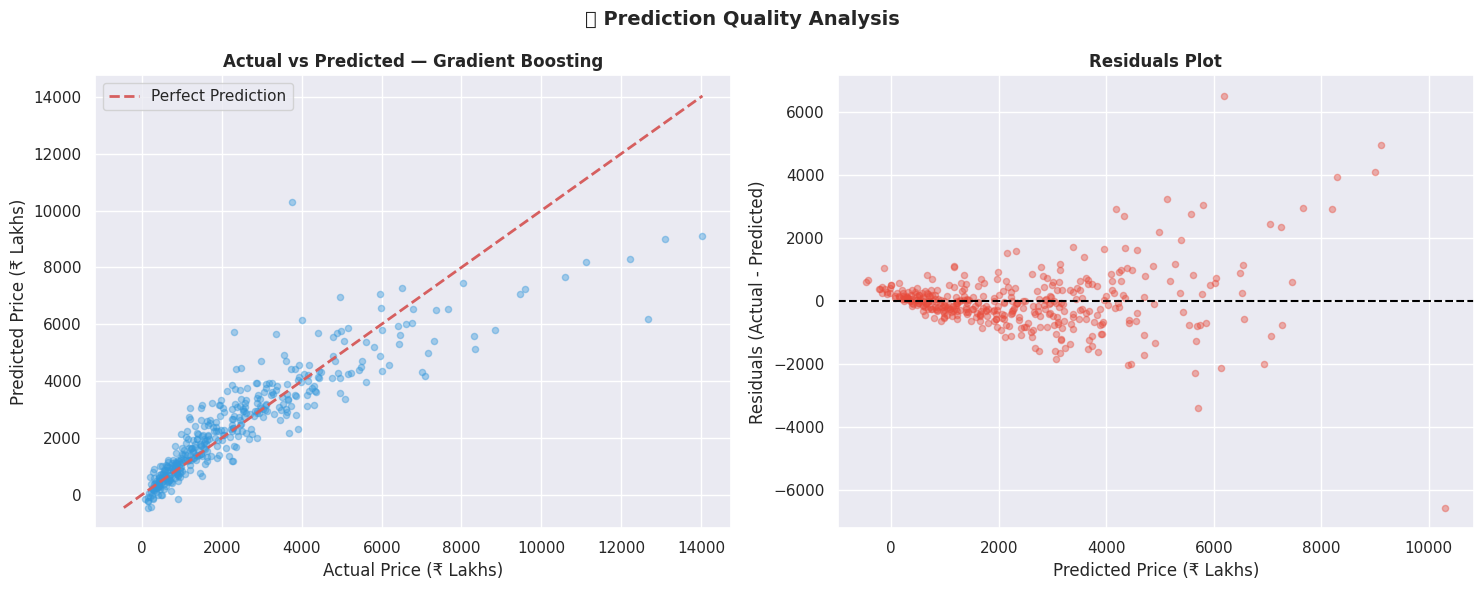

In [13]:
best_preds = results[best_name]['preds']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted scatter
axes[0].scatter(y_test, best_preds, alpha=0.4, color='#3498db', s=20)
mn = min(y_test.min(), best_preds.min())
mx = max(y_test.max(), best_preds.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted — {best_name}', fontweight='bold')
axes[0].set_xlabel('Actual Price (₹ Lakhs)')
axes[0].set_ylabel('Predicted Price (₹ Lakhs)')
axes[0].legend()

# Residuals plot
residuals = y_test.values - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.4, color='#e74c3c', s=20)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Plot', fontweight='bold')
axes[1].set_xlabel('Predicted Price (₹ Lakhs)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

plt.suptitle('📈 Prediction Quality Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight', dpi=150)
plt.show()

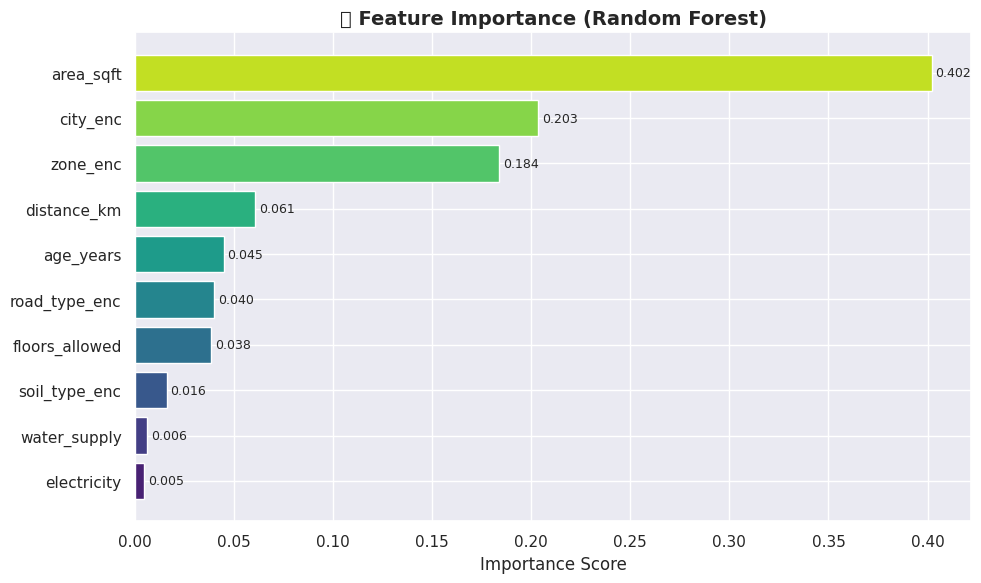

In [14]:
# Use Random Forest feature importances
importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
                color=sns.color_palette('viridis', len(importance_df)))
plt.title('🌟 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
for bar, val in zip(bars, importance_df['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

In [15]:
# ── Encoders for all categories ───────────────────────────────────────────
encoders = {}
for col in cat_cols:
    enc = LabelEncoder()
    enc.fit(df[col])
    encoders[col] = enc

def predict_price(city, zone, road_type, soil_type,
                  area_sqft, distance_km, floors_allowed,
                  age_years, water_supply, electricity):
    """
    Predicts land price in ₹ Lakhs for given inputs.

    city          : Mumbai / Delhi / Bangalore / Hyderabad / Chennai /
                    Pune / Kolkata / Ahmedabad / Jaipur / Lucknow
    zone          : Commercial / Residential / Industrial / Agricultural
    road_type     : Highway / Main Road / Internal Road / No Road
    soil_type     : Rocky / Clay / Sandy / Loamy
    area_sqft     : integer (e.g. 2000)
    distance_km   : float  (e.g. 5.0)
    floors_allowed: integer (1-10)
    age_years     : integer (0-30)
    water_supply  : 1 = Yes, 0 = No
    electricity   : 1 = Yes, 0 = No
    """
    try:
        row = {
            'city_enc'      : encoders['city'].transform([city])[0],
            'zone_enc'      : encoders['zone'].transform([zone])[0],
            'road_type_enc' : encoders['road_type'].transform([road_type])[0],
            'soil_type_enc' : encoders['soil_type'].transform([soil_type])[0],
            'area_sqft'     : area_sqft,
            'distance_km'   : distance_km,
            'floors_allowed': floors_allowed,
            'age_years'     : age_years,
            'water_supply'  : water_supply,
            'electricity'   : electricity,
        }
        X_new = pd.DataFrame([row])[feature_cols]

        pred_rf = rf.predict(X_new)[0]
        pred_gb = gb.predict(X_new)[0]
        pred_lr = lr.predict(scaler.transform(X_new))[0]

        print(f'\n🏡 Land Price Prediction')
        print('=' * 45)
        print(f'  City           : {city}')
        print(f'  Zone           : {zone}')
        print(f'  Road Type      : {road_type}')
        print(f'  Soil Type      : {soil_type}')
        print(f'  Area           : {area_sqft:,} sq ft')
        print(f'  Distance       : {distance_km} km from center')
        print(f'  Floors Allowed : {floors_allowed}')
        print(f'  Age            : {age_years} years')
        print(f'  Water Supply   : {"Yes" if water_supply else "No"}')
        print(f'  Electricity    : {"Yes" if electricity else "No"}')
        print(f'\n  💰 Predicted Price:')
        print(f'     Linear Regression  : ₹ {pred_lr:>10.2f} Lakhs')
        print(f'     Random Forest      : ₹ {pred_rf:>10.2f} Lakhs')
        print(f'     Gradient Boosting  : ₹ {pred_gb:>10.2f} Lakhs')
        avg = np.mean([pred_lr, pred_rf, pred_gb])
        print(f'\n  🏆 Ensemble Average    : ₹ {avg:>10.2f} Lakhs')
        print(f'              (approx. ₹ {avg*1e5/1e7:.2f} Crore)')

    except ValueError as e:
        print(f'❌ Invalid input: {e}')
        print('   Please check city / zone / road_type / soil_type values above.')

# ── Example prediction ────────────────────────────────────────────────────
predict_price(
    city           = 'Pune',
    zone           = 'Residential',
    road_type      = 'Main Road',
    soil_type      = 'Loamy',
    area_sqft      = 2400,
    distance_km    = 6.5,
    floors_allowed = 4,
    age_years      = 5,
    water_supply   = 1,
    electricity    = 1,
)


🏡 Land Price Prediction
  City           : Pune
  Zone           : Residential
  Road Type      : Main Road
  Soil Type      : Loamy
  Area           : 2,400 sq ft
  Distance       : 6.5 km from center
  Floors Allowed : 4
  Age            : 5 years
  Water Supply   : Yes
  Electricity    : Yes

  💰 Predicted Price:
     Linear Regression  : ₹    1497.84 Lakhs
     Random Forest      : ₹    1369.55 Lakhs
     Gradient Boosting  : ₹    1623.01 Lakhs

  🏆 Ensemble Average    : ₹    1496.80 Lakhs
              (approx. ₹ 14.97 Crore)


In [16]:
# ✍️ Try YOUR OWN land details — change values below!
predict_price(
    city           = 'Mumbai',       # city name
    zone           = 'Commercial',   # Commercial / Residential / Industrial / Agricultural
    road_type      = 'Highway',      # Highway / Main Road / Internal Road / No Road
    soil_type      = 'Sandy',        # Rocky / Clay / Sandy / Loamy
    area_sqft      = 5000,           # land area in sq ft
    distance_km    = 3.0,            # km from city center
    floors_allowed = 6,              # number of floors allowed
    age_years      = 2,              # age of registration in years
    water_supply   = 1,              # 1 = Yes, 0 = No
    electricity    = 1,              # 1 = Yes, 0 = No
)


🏡 Land Price Prediction
  City           : Mumbai
  Zone           : Commercial
  Road Type      : Highway
  Soil Type      : Sandy
  Area           : 5,000 sq ft
  Distance       : 3.0 km from center
  Floors Allowed : 6
  Age            : 2 years
  Water Supply   : Yes
  Electricity    : Yes

  💰 Predicted Price:
     Linear Regression  : ₹    3849.70 Lakhs
     Random Forest      : ₹    6811.19 Lakhs
     Gradient Boosting  : ₹    8381.92 Lakhs

  🏆 Ensemble Average    : ₹    6347.60 Lakhs
              (approx. ₹ 63.48 Crore)


In [17]:
print('=' * 60)
print('🏡  LAND PRICE PREDICTION — SUMMARY')
print('=' * 60)
print(f'📁 Total Records          : {len(df):,}')
print(f'🌆 Cities Covered         : {", ".join(sorted(df["city"].unique()))}')
print(f'📐 Avg Land Area          : {df["area_sqft"].mean():,.0f} sq ft')
print(f'💰 Avg Land Price         : ₹ {df["price_lakhs"].mean():.2f} Lakhs')
print(f'💰 Price Range            : ₹ {df["price_lakhs"].min():.1f}L — ₹ {df["price_lakhs"].max():.1f}L')
print(f'\n🤖 Model Results:')
for k, v in results.items():
    flag = ' 🏆 Best' if k == best_name else ''
    print(f'   {k:<22}: R² = {v["R2"]*100:.2f}%  |  MAE = ₹{v["MAE"]:.1f}L{flag}')
print('\n✅ Analysis Complete!')

🏡  LAND PRICE PREDICTION — SUMMARY
📁 Total Records          : 2,000
🌆 Cities Covered         : Ahmedabad, Bangalore, Chennai, Delhi, Hyderabad, Jaipur, Kolkata, Lucknow, Mumbai, Pune
📐 Avg Land Area          : 5,176 sq ft
💰 Avg Land Price         : ₹ 2532.56 Lakhs
💰 Price Range            : ₹ 61.8L — ₹ 18077.3L

🤖 Model Results:
   Linear Regression     : R² = 37.96%  |  MAE = ₹1220.5L
   Random Forest         : R² = 75.62%  |  MAE = ₹723.6L
   Gradient Boosting     : R² = 80.10%  |  MAE = ₹603.3L 🏆 Best

✅ Analysis Complete!
